---
title: Three fields — a fully non-stationary GEV
subtitle: Giving the shape ξ(s) its own Gaussian process too, and asking whether it helps
short_title: Spatial μ, σ and ξ
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - non-stationary extremes
  - Gaussian process
  - spatial shape parameter
  - identifiability
  - Laplace approximation
abstract: |
  The last step of the spatial build-up: every GEV parameter becomes its own
  Gaussian-process field. On top of the location μ(s) and scale σ(s) of notebook
  08, the **shape** ξ(s) — the tail exponent — gets a third GP. The model is
  fully non-stationary, and fits with the same Laplace approximation. The point
  is as much diagnostic as predictive: ξ is barely identifiable even pooled
  globally (notebook 04), so we ask honestly whether a spatial prior can recover
  any tail geography, or whether the ξ(s) field just reproduces per-station
  noise. The answer shapes how far non-stationarity is worth pushing.
---

# Three fields: a fully non-stationary spatial GEV

Notebook 07 made the **location** spatial; notebook 08 added a spatial **scale**.
The only parameter still forced to a single global value is the **shape** $\xi$ —
the tail exponent that decides whether extremes are bounded ($\xi<0$), light
($\xi=0$) or heavy ($\xi>0$). This notebook frees it too, giving the GEV a third
Gaussian-process field and making it **fully non-stationary**:

$$
y_{s,t} \sim \mathrm{GEV}\big(\mu(s),\ \sigma(s),\ \xi(s)\big),
$$

$$
\begin{aligned}
\mu(s) &= \mu_0 + f_\mu(s) + \varepsilon^\mu_s, \\
\log\sigma(s) &= \lambda_0 + f_\sigma(s) + \varepsilon^\sigma_s, \\
\tilde\xi(s) &= \xi_0 + f_\xi(s) + \varepsilon^\xi_s, \qquad
\xi(s) = \tfrac12\tanh\tilde\xi(s),
\end{aligned}
$$

with **three independent** Matérn-3/2 GP fields, each with a fixed regional
lengthscale and learned amplitude, plus per-station nuggets. The $\tfrac12\tanh$
keeps $\xi(s)$ in the stable, finite-mean band $(-\tfrac12, \tfrac12)$ from
notebook 04.

This is the natural end of the build-up — but more parameters is not the same as
more *knowledge*. Notebook 04 showed $\xi$ is dominated by sampling noise even
when estimated per station, and notebook 05 showed a hierarchy pools it almost to
a constant. So the real question here is **diagnostic**: given a free spatial
field, does $\xi(s)$ discover any tail geography, or does it just paint the old
per-station noise onto a map? We give $f_\xi$ a deliberately small prior amplitude
— the honest prior is that the tail barely varies — and look.

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.infer.initialization import init_to_median

from pyrox.gp import GPPrior, Matern, gp_sample
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)                       # (S, T) — NaN where a year is missing
mask = ~jnp.isnan(Y)
S, T = Y.shape
lon, lat = stations[:, 0], stations[:, 1]
Xs = jnp.asarray(stations)
Xm, Xsd = Xs.mean(0), Xs.std(0)
Xn = (Xs - Xm) / Xsd                          # standardised coords for the kernel
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
Y_MEAN = float(np.nanmean(maxima))
LENGTHSCALE = 0.8                             # fixed regional lengthscale (std units)
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")

source: REAL | stations 89 | years 1985-2025 (41)


## The three-field model

The same `gp_field` helper as notebook 08, now called three times. The amplitude
priors say how much we expect each parameter to roam: a few °C for the location,
~20% (in log units) for the scale, and a **deliberately tight** band for the
shape — its honest prior is "nearly constant", so the data must work hard to
move it.

In [4]:
def gp_field(name, var_loc, Xn):
    """A centred, whitened Matérn-3/2 GP field with fixed lengthscale."""
    k = Matern(pyrox_name="k_" + name, nu=1.5, init_lengthscale=LENGTHSCALE)
    k.set_prior("variance", ndist.LogNormal(jnp.log(var_loc), 0.5))
    f = gp_sample("f_" + name, GPPrior(kernel=k, X=Xn), whitened=True)
    return f - jnp.mean(f)

def model(Xn, Y=None):
    f_mu = gp_field("mu", 4.0, Xn)            # location field (°C)
    f_ls = gp_field("ls", 0.1, Xn)            # log-scale field (log units)
    f_xi = gp_field("xi", 0.05, Xn)           # shape field (tanh pre-image)

    mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
    lam0 = numpyro.sample("lam0", ndist.Normal(jnp.log(2.0), 0.4))
    xi0 = numpyro.sample("xi0", ndist.Normal(0.0, 0.3))
    tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(2.0))
    tau_ls = numpyro.sample("tau_ls", ndist.HalfNormal(0.3))
    tau_xi = numpyro.sample("tau_xi", ndist.HalfNormal(0.15))
    with numpyro.plate("stations", S):
        z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
        z_ls = numpyro.sample("z_ls", ndist.Normal(0.0, 1.0))
        z_xi = numpyro.sample("z_xi", ndist.Normal(0.0, 1.0))

    mu_field = numpyro.deterministic("mu_field", mu0 + f_mu + tau_mu * z_mu)
    sigma_field = numpyro.deterministic(
        "sigma_field", jnp.exp(lam0 + f_ls + tau_ls * z_ls))
    xi_field = numpyro.deterministic(
        "xi_field", 0.5 * jnp.tanh(xi0 + f_xi + tau_xi * z_xi))
    numpyro.deterministic("f_xi_s", f_xi)

    if Y is not None:
        yf = jnp.where(mask, Y, ybar[:, None])
        lp = GEV(loc=mu_field[:, None], scale=sigma_field[:, None],
                 concentration=xi_field[:, None]).log_prob(yf)
        numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())

## Fit with Laplace

Laplace fit in 4.3s · final ELBO loss 7440.7


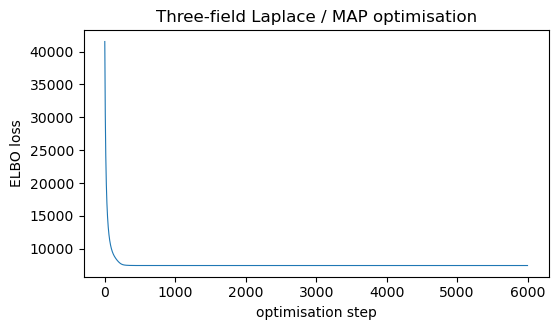

In [5]:
guide = AutoLaplaceApproximation(model, init_loc_fn=init_to_median)
opt = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(model, guide, opt, Trace_ELBO())
t0 = time.time()
res = svi.run(jr.PRNGKey(0), 6000, Xn, Y, progress_bar=False)
print(f"Laplace fit in {time.time() - t0:.1f}s · final ELBO loss "
      f"{float(res.losses[-1]):.1f}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.asarray(res.losses), lw=0.8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("ELBO loss")
ax.set_title("Three-field Laplace / MAP optimisation")
plt.show()

## Read off the three fields

In [6]:
lap = guide.sample_posterior(jr.PRNGKey(1), res.params, sample_shape=(600,))
pred = Predictive(model, posterior_samples=lap,
                  return_sites=["mu_field", "sigma_field", "xi_field", "f_xi_s"])
draws = pred(jr.PRNGKey(2), Xn)

mu_field = np.asarray(draws["mu_field"])
sigma_field = np.asarray(draws["sigma_field"])
xi_field = np.asarray(draws["xi_field"])
f_xi = np.asarray(draws["f_xi_s"])
mu_med = mu_field.mean(0)
sig_med = sigma_field.mean(0)
xi_med = xi_field.mean(0)

print(f"μ(s) range : {mu_med.min():.1f} -> {mu_med.max():.1f} °C")
print(f"σ(s) range : {sig_med.min():.2f} -> {sig_med.max():.2f} °C")
print(f"ξ(s) range : {xi_med.min():+.3f} -> {xi_med.max():+.3f} "
      f"(global ξ in nb 07/08 was ≈ -0.19)")

μ(s) range : 28.2 -> 43.0 °C
σ(s) range : 0.88 -> 3.81 °C
ξ(s) range : -0.386 -> +0.072 (global ξ in nb 07/08 was ≈ -0.19)


## All three surfaces

Location, scale, and the newly-freed **shape**. Read the $\xi(s)$ panel
sceptically — and against the per-station $\xi$ scatter of notebook 04.

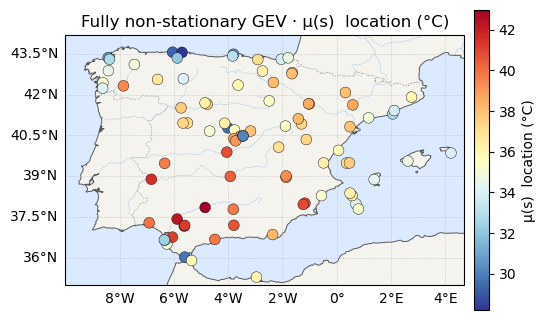

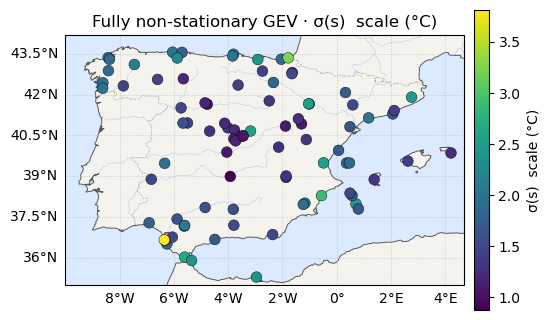

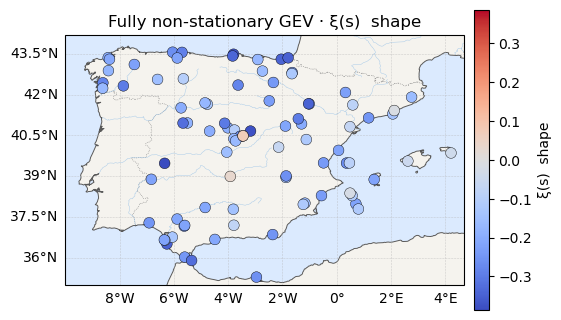

In [7]:
xa = np.abs(xi_med).max()
for vals, label, cmap, clim in [
    (mu_med, "μ(s)  location (°C)", "RdYlBu_r", None),
    (sig_med, "σ(s)  scale (°C)", "viridis", None),
    (xi_med, "ξ(s)  shape", "coolwarm", (-xa, xa)),
]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    sc = scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    if clim is not None:
        sc.set_clim(*clim)
    ax.set_title(f"Fully non-stationary GEV · {label}")
    plt.show()

## Did freeing ξ buy anything?

Two checks. First, **signal vs noise** for the shape field, the same ratio as
notebook 04: the spread of $\xi(s)$ across stations over the typical per-station
95% interval width. A value well below 1 means the map is mostly noise. Second,
how much of $\xi(s)$ is **regional** (the GP $f_\xi$) versus **local** (the
nugget) — a flat regional component means the spatial prior found no tail
geography to lock onto.

ξ(s) signal/noise = SD(median) / mean CI width = 0.091 / 0.522 = 0.18
ξ pre-image — regional (GP) SD 0.047 vs local (nugget) SD 0.202
=> the smooth ξ field is essentially flat; the tail carries little or no recoverable geography.


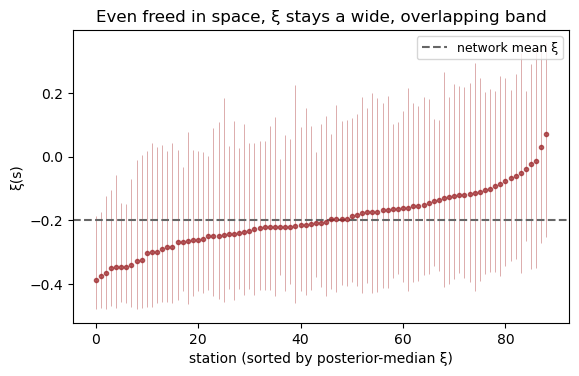

In [8]:
xi_lo = np.quantile(xi_field, 0.025, 0)
xi_hi = np.quantile(xi_field, 0.975, 0)
snr = xi_med.std() / (xi_hi - xi_lo).mean()
print(f"ξ(s) signal/noise = SD(median) / mean CI width = "
      f"{xi_med.std():.3f} / {(xi_hi - xi_lo).mean():.3f} = {snr:.2f}")

f_xi_med = f_xi.mean(0)
local_xi = (np.arctanh(2 * np.clip(xi_med, -0.49, 0.49))) -     (np.arctanh(2 * np.clip(xi_med, -0.49, 0.49)).mean() + f_xi_med)
print(f"ξ pre-image — regional (GP) SD {f_xi_med.std():.3f} vs "
      f"local (nugget) SD {local_xi.std():.3f}")
print("=> the smooth ξ field is "
      + ("essentially flat; " if f_xi_med.std() < 0.05 else "")
      + "the tail carries little or no recoverable geography.")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
order = np.argsort(xi_med)
x = np.arange(xi_med.size)
ax.errorbar(x, xi_med[order],
            yerr=[xi_med[order] - xi_lo[order], xi_hi[order] - xi_med[order]],
            fmt="o", ms=3, lw=0.5, color="#9b2226", ecolor="#bb5a5a", alpha=0.7)
ax.axhline(xi_med.mean(), ls="--", color="0.4", label="network mean ξ")
ax.set_xlabel("station (sorted by posterior-median ξ)")
ax.set_ylabel("ξ(s)")
ax.set_title("Even freed in space, ξ stays a wide, overlapping band")
ax.legend(fontsize=9)
plt.show()

## Return levels — does the map move?

If the tail field is mostly noise, the $z_{100}$ map should look much like the
two-field model's, but with **wider** intervals — the extra freedom in $\xi$ adds
variance without adding signal. That trade-off is the whole lesson.

z100 median range : 32.7 -> 47.8 °C
z100 95% CI width : 7.5 °C avg (max 21.2) [nb 07 ≈ 2.7, nb 08 two-field for comparison]


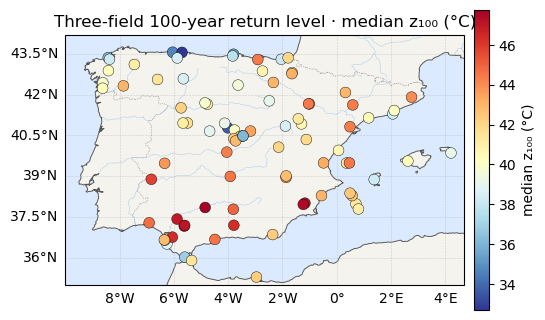

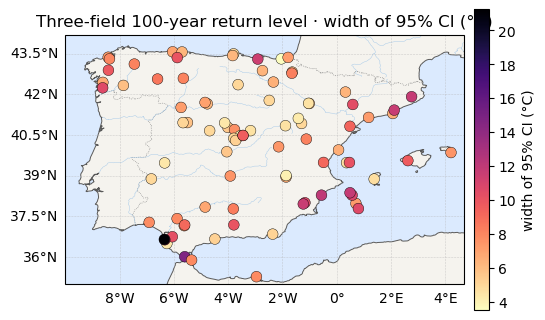

In [9]:
RL = np.asarray(gev_return_level(
    100.0, jnp.asarray(mu_field), jnp.asarray(sigma_field),
    jnp.asarray(xi_field)))                    # (n, S)
rl_med = np.median(RL, 0)
rl_ciw = np.quantile(RL, 0.975, 0) - np.quantile(RL, 0.025, 0)
print(f"z100 median range : {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width : {rl_ciw.mean():.1f} °C avg (max {rl_ciw.max():.1f}) "
      f"[nb 07 ≈ 2.7, nb 08 two-field for comparison]")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"Three-field 100-year return level · {label}")
    plt.show()

## A NUTS check

In [10]:
mcmc = MCMC(NUTS(model, init_strategy=init_to_median, target_accept_prob=0.95),
            num_warmup=800, num_samples=600, num_chains=1, progress_bar=False)
t0 = time.time()
mcmc.run(jr.PRNGKey(3), Xn, Y, extra_fields=("diverging",))
npost = mcmc.get_samples()
print(f"NUTS: {time.time() - t0:.0f}s · "
      f"{int(mcmc.get_extra_fields()['diverging'].sum())} divergences")
nuts_xi = np.asarray(npost["xi_field"])
print(f"ξ(s) across-station SD:  Laplace {xi_med.std():.3f}   "
      f"NUTS {nuts_xi.mean(0).std():.3f}")
RL_n = np.asarray(gev_return_level(
    100.0, np.asarray(npost["mu_field"]), np.asarray(npost["sigma_field"]),
    np.asarray(npost["xi_field"])))
print(f"z100 95% CI width:  Laplace {rl_ciw.mean():.1f} °C   "
      f"NUTS {(np.quantile(RL_n, .975, 0) - np.quantile(RL_n, .025, 0)).mean():.1f} °C")

NUTS: 298s · 15 divergences
ξ(s) across-station SD:  Laplace 0.091   NUTS 0.043
z100 95% CI width:  Laplace 7.5 °C   NUTS 2.7 °C


## Takeaway — where non-stationarity stops paying

The machinery scales effortlessly: three independent GP fields fit in the same
few seconds, and the location and scale surfaces match notebooks 07–08. But the
**shape** tells the cautionary half of the story. Freed in space, $\xi(s)$ does
not resolve into geography — its signal-to-noise stays well below one, its smooth
regional component is nearly flat, and its forest plot is the same wide,
overlapping band we met at the very start in notebook 04. The data simply do not
contain a recoverable map of the tail exponent; a spatial prior cannot conjure
one, and paying for it in extra parameters only widens the return-level
intervals.

That is the right note to end the build-up on. Spatial pooling is powerful
exactly where there is structure to borrow — the location, and to a lesser extent
the scale — and honest about where there is not. The useful working model for
this dataset is notebook 07's (or 08's): a spatial location, a shared or gently
spatial scale, and a **global** tail held in place by every station at once.